# ⚾ 카운트 기반 Run Value로 재대결 타석 전체 투구 반영하기

* **작성자:** DY
* **작성일:** 2026-10-05
* **목적:** 노트북 3은 재대결 타석의 **결정구 하나만** 평가합니다(`woba_value`가 그 투구에만 있기 때문).
  이 노트북은 "결정구가 아닌 투구는 보상(타깃)이 없다"는 제약을 **볼카운트 기반 Run Value**로 풀어서,
  재대결 타석의 **모든 투구**를 반영한 RVAE를 다시 계산합니다.
  * 볼카운트별로 "그 카운트를 거친 타석들의 평균 최종 결과"를 테이블로 만들고, 투구 하나의 Run Value =
    (다음 카운트의 기댓값, 또는 그 투구가 타석을 끝냈으면 실제 결과) − (현재 카운트의 기댓값)으로 정의합니다.
    베이스-아웃 상태 재구성이 필요 없어 기존 컬럼(`balls`/`strikes`)만으로 충분하고, 커버리지가 결정구만
    쓸 때의 25.5%에서 전체 투구의 99.96%로 늘어납니다(실측 확인).
  * 공의 품질(구속·무브먼트·코스)은 노트북 3과 동일하게 제외합니다 — 상황+구종+구사율만 씁니다.
  * 메인 결과는 노트북 3과 같은 틀(회피율 3분위 그룹 간 RVAE 비교)이지만, RVAE가 "결정구 하나"가 아니라
    "재대결 타석 전체 투구의 합"으로 바뀝니다.
* **설계 문서:** `docs/superpowers/specs/2026-10-03-run-value-gbm-pitcher-tendency-design.md` (노트북 3과
  공유; 타깃 정의와 학습 단위가 다른 별도 분석입니다)

In [1]:
# 1. 경로 설정 (src 폴더 접근용)
import sys, os
sys.path.append(os.path.abspath('..'))

# 2. Autoreload 설정
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from src.analysis.avoidance_stats import compute_season_usage_rate, summarize_diff_in_diff
from src.analysis.run_same_batter_rematch_analysis import build_xbh_rematch
from src.preprocessing.research_sample import KEY_COLUMNS, list_research_csvs
from src.visualization.pitch_type_reuse_plots import _use_korean_font

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)
_use_korean_font()

MIN_USAGE_RATE = 0.05
MIN_REMATCH_EVENTS = 10
MIN_SEASON_EVENTS = 5
TRAIN_SEASONS = (2021, 2022, 2023, 2024, 2025)
VALID_SEASON = 2026
RANDOM_STATE = 20261003

Error importing in API mode: ImportError("dlopen(/Users/dongyunkwak/GitHub/9th-first-project-baseball-2/.venv/lib/python3.14/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.6/Resources/lib/libRblas.dylib\n  Referenced from: <9F0E20C3-D782-31B5-943E-66F62BCE77E8> /Users/dongyunkwak/GitHub/9th-first-project-baseball-2/.venv/lib/python3.14/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.6/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.6/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.6/Resources/lib/libRblas.dylib' (no such file)")


Trying to import in ABI mode.


## 1. 팀 CSV 읽기

`data/raw` 없이 팀 research CSV 6개를 읽습니다. `woba_value`/`woba_denom`은 그 타석을 끝낸 결정구에만 채워져 있고
(실측 확인됨), 이게 GBM의 학습·평가 단위(타석이 아니라 결정구 하나)를 정합니다.

In [2]:
LOAD_COLUMNS = [
    'game_pk', 'game_date', 'at_bat_number', 'pitch_number', 'pitcher', 'player_name', 'batter',
    'stand', 'p_throws', 'pitch_type', 'events', 'balls', 'strikes', 'outs_when_up',
    'inning', 'inning_topbot', 'on_1b', 'on_2b', 'on_3b', 'home_score', 'away_score',
    'woba_value', 'woba_denom',
]


def load_team_csv() -> pd.DataFrame:
    frames = [
        pd.read_csv(path, usecols=LOAD_COLUMNS, encoding='utf-8-sig', low_memory=False)
        for path in list_research_csvs()
    ]
    pitches = pd.concat(frames, ignore_index=True)
    pitches['season'] = pd.to_datetime(pitches['game_date']).dt.year
    return pitches


pitches = load_team_csv()
assert len(pitches) == 3_592_302 and pitches['pitcher'].nunique() == 1_067
assert not pitches.duplicated(KEY_COLUMNS).any()
print(f'{len(pitches):,}행, 투수 {pitches["pitcher"].nunique():,}명')

3,592,302행, 투수 1,067명


## 2. 상황 피처

`score_diff`는 `src/preprocessing/build_next_ab_dataset.py`의 `compute_score_diff()`와 같은 정의(투수팀 관점,
수비팀 − 공격팀)를 벡터화한 것입니다.

In [3]:
SITUATION_COLUMNS = ['runners_n', 'risp', 'score_diff', 'platoon_match']


def add_situation_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    on1, on2, on3 = out['on_1b'].notna(), out['on_2b'].notna(), out['on_3b'].notna()
    out['runners_n'] = on1.astype(int) + on2.astype(int) + on3.astype(int)
    out['risp'] = (on2 | on3).astype(int)
    out['score_diff'] = np.where(
        out['inning_topbot'] == 'Top', out['home_score'] - out['away_score'], out['away_score'] - out['home_score']
    )
    out['platoon_match'] = np.where(
        out['stand'].isna() | out['p_throws'].isna(), np.nan, (out['stand'] == out['p_throws']).astype(float)
    )
    return out

In [4]:
_t = pd.DataFrame({
    'on_1b': [np.nan, 1.0, np.nan], 'on_2b': [np.nan, np.nan, 2.0], 'on_3b': [np.nan, np.nan, np.nan],
    'inning_topbot': ['Top', 'Bot', 'Top'], 'home_score': [3, 5, 2], 'away_score': [3, 2, 4],
    'stand': ['L', 'R', 'R'], 'p_throws': ['R', 'R', 'L'],
})
_r = add_situation_columns(_t)
assert _r['runners_n'].tolist() == [0, 1, 1]
assert _r['risp'].tolist() == [0, 0, 1]
assert _r['score_diff'].tolist() == [0, -3, -2]
assert _r['platoon_match'].tolist() == [0.0, 1.0, 0.0]
print('add_situation_columns 테스트 통과')

add_situation_columns 테스트 통과


In [5]:
pitches = add_situation_columns(pitches)
print(pitches[SITUATION_COLUMNS].describe().round(3))

         runners_n         risp   score_diff  platoon_match
count  3592302.000  3592302.000  3592302.000    3592302.000
mean         0.580        0.237        0.189          0.447
std          0.775        0.425        2.936          0.497
min          0.000        0.000      -25.000          0.000
25%          0.000        0.000       -1.000          0.000
50%          0.000        0.000        0.000          0.000
75%          1.000        0.000        2.000          1.000
max          3.000        1.000       24.000          1.000


## 3. 재대결 이벤트와 투수별 회피율

장타 재대결 이벤트는 노트북 01·02와 같은 건수(27,391건)가 나와야 합니다. 회피율 = 1 − 평균(`reused_same_type`).

In [6]:
season_usage = compute_season_usage_rate(pitches)
xbh = build_xbh_rematch(pitches, season_usage)
xbh = xbh[xbh['has_next_ab']].copy()
assert len(xbh) == 27_391, len(xbh)
print(f'재대결 이벤트 {len(xbh):,}건')

2026-10-05 15:52:20,502 [INFO] 장타 70319건 중 같은 타자·같은 투수 재대결 27391건 (39.0%)
        xbh_total  same_batter_rematch  rematch_share
season                                               
2021        12709                 4688         0.3689
2022        12186                 4623         0.3794
2023        13137                 5280         0.4019
2024        12427                 4977         0.4005
2025        12394                 4916         0.3966
2026         7466                 2907         0.3894


재대결 이벤트 27,391건


In [7]:
def _agg_rate(events: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    g = events.groupby(group_cols)['reused_same_type']
    out = g.agg(n_events='size', reuse_rate='mean').reset_index()
    out['avoidance_rate'] = 1 - out['reuse_rate']
    return out.drop(columns='reuse_rate')


def season_rate(events: pd.DataFrame) -> pd.DataFrame:
    return _agg_rate(events, ['pitcher', 'season'])


def pitcher_rate(events: pd.DataFrame) -> pd.DataFrame:
    return _agg_rate(events, ['pitcher'])

In [8]:
_e = pd.DataFrame({
    'pitcher': [1, 1, 1, 2, 2], 'season': [2021, 2021, 2022, 2021, 2021],
    'reused_same_type': [1, 0, 0, 1, 1],
})
_s = season_rate(_e)
assert _s.set_index(['pitcher', 'season'])['n_events'].to_dict() == {(1, 2021): 2, (1, 2022): 1, (2, 2021): 2}
assert np.isclose(_s.set_index(['pitcher', 'season']).loc[(1, 2021), 'avoidance_rate'], 0.5)
_p = pitcher_rate(_e)
assert _p.set_index('pitcher')['n_events'].to_dict() == {1: 3, 2: 2}
assert np.isclose(_p.set_index('pitcher').loc[1, 'avoidance_rate'], 1 - 1 / 3)
assert np.isclose(_p.set_index('pitcher').loc[2, 'avoidance_rate'], 0.0)
print('회피율 집계 테스트 통과')

회피율 집계 테스트 통과


## 4. 시즌 안정성 검증

회피율을 2021–2026 전체 합산으로 다루기 전에, 투수-시즌 회피율(자격: 그 시즌 재대결 5건 이상, 2개 시즌 이상 자격)이
얼마나 그 투수의 안정적 특성인지 확인합니다. η² = (투수 간 분산) / (전체 분산)인데, 그룹 수(투수)가 많고
그룹당 표본(시즌 수)이 적으면 위로 치우치는 성질이 있어 편향 보정한 ω²도 같이 봅니다. 진행 여부와 무관하게 보고용입니다.

In [9]:
def eta_squared(df: pd.DataFrame, group_col: str, value_col: str) -> float:
    grand_mean = df[value_col].mean()
    total_ss = ((df[value_col] - grand_mean) ** 2).sum()
    if total_ss == 0:
        return float('nan')
    group_means = df.groupby(group_col)[value_col].transform('mean')
    between_ss = ((group_means - grand_mean) ** 2).sum()
    # transform('mean')은 행마다 그 그룹 평균을 반복하므로, 그룹별 가중합이 되도록 그대로 합산해도
    # 각 행이 자기 그룹 평균과의 편차 제곱합에 기여하는 구조(중복 합산 아님)
    return float(between_ss / total_ss)


def omega_squared(df: pd.DataFrame, group_col: str, value_col: str) -> float:
    """편향 보정한 분산 비율. eta_squared는 그룹 수(k)가 많고 그룹당 표본이 적을수록 위로 치우치는데,
    omega_squared = (SS_between - (k-1)*MS_within) / (SS_total + MS_within)는 그 편향을 보정한다.
    순수 잡음(그룹 효과가 전혀 없음)이면 음수가 나올 수 있다 -- 버그가 아니라 정상적인 동작이다.
    """
    grand_mean = df[value_col].mean()
    n = len(df)
    k = df[group_col].nunique()
    total_ss = ((df[value_col] - grand_mean) ** 2).sum()
    if total_ss == 0 or n <= k:
        return float('nan')
    group_means = df.groupby(group_col)[value_col].transform('mean')
    between_ss = ((group_means - grand_mean) ** 2).sum()
    ms_within = (total_ss - between_ss) / (n - k)
    return float((between_ss - (k - 1) * ms_within) / (total_ss + ms_within))

In [10]:
_stable = pd.DataFrame({'pitcher': [1, 1, 2, 2], 'rate': [0.8, 0.8, 0.2, 0.2]})
assert np.isclose(eta_squared(_stable, 'pitcher', 'rate'), 1.0)

_noisy = pd.DataFrame({'pitcher': [1, 1, 2, 2], 'rate': [0.8, 0.2, 0.8, 0.2]})
assert np.isclose(eta_squared(_noisy, 'pitcher', 'rate'), 0.0)

# eta_squared는 그룹 수가 많고 그룹당 표본이 적으면 위로 치우친다(리뷰 지적). 편향 보정한 omega_squared를 같이 본다.
assert np.isclose(omega_squared(_stable, 'pitcher', 'rate'), 1.0)
assert np.isclose(omega_squared(_noisy, 'pitcher', 'rate'), -1 / 3)  # 순수 잡음이면 음수가 나올 수 있음(정상)
print('eta_squared 테스트 통과')

eta_squared 테스트 통과


In [11]:
season_rates = season_rate(xbh)
season_rates = season_rates[season_rates['n_events'] >= MIN_SEASON_EVENTS]
multi_season = season_rates[season_rates.groupby('pitcher')['pitcher'].transform('size') >= 2]
print(f'시즌당 {MIN_SEASON_EVENTS}건 이상, 2개 시즌 이상 자격인 투수 {multi_season["pitcher"].nunique()}명 '
      f'({len(multi_season)}개 투수-시즌)')
eta2 = eta_squared(multi_season, 'pitcher', 'avoidance_rate')
omega2 = omega_squared(multi_season, 'pitcher', 'avoidance_rate')
print(f'eta-squared (투수 간 분산 비율, 편향 보정 전): {eta2:.3f}')
print(f'omega-squared (편향 보정 후, 그룹 수가 많고 그룹당 표본이 적어 eta-squared가 위로 치우치는 것을 보정): {omega2:.3f}')

pairs = (
    multi_season.sort_values(['pitcher', 'season'])
    .assign(next_rate=lambda d: d.groupby('pitcher')['avoidance_rate'].shift(-1),
            next_season=lambda d: d.groupby('pitcher')['season'].shift(-1))
    .dropna(subset=['next_rate'])
)
pairs = pairs[pairs['next_season'] == pairs['season'] + 1]
corr = pairs['avoidance_rate'].corr(pairs['next_rate'])
print(f'인접 시즌 회피율 상관계수 (n={len(pairs)} 쌍): {corr:.3f}')

시즌당 5건 이상, 2개 시즌 이상 자격인 투수 332명 (1169개 투수-시즌)
eta-squared (투수 간 분산 비율, 편향 보정 전): 0.474
omega-squared (편향 보정 후, 그룹 수가 많고 그룹당 표본이 적어 eta-squared가 위로 치우치는 것을 보정): 0.266
인접 시즌 회피율 상관계수 (n=760 쌍): 0.337


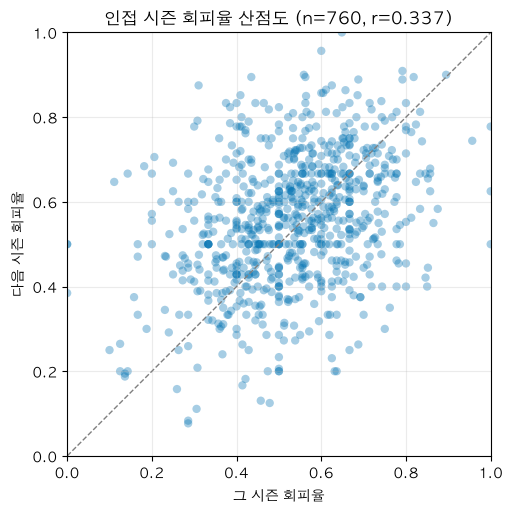

In [12]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(pairs['avoidance_rate'], pairs['next_rate'], alpha=0.35, color='#0072B2', edgecolors='none')
ax.plot([0, 1], [0, 1], color='gray', lw=1, ls='--')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('그 시즌 회피율')
ax.set_ylabel('다음 시즌 회피율')
ax.set_title(f'인접 시즌 회피율 산점도 (n={len(pairs)}, r={corr:.3f})')
ax.grid(alpha=0.25)
plt.show()

## 5. 포함 기준과 그룹화

설계대로 **투수 1명(2021–2026 전체 합산)** 단위로 분석합니다. 4절에서 ω²=0.266으로 나온 것은 회피 성향의
변동 중 투수 간 차이가 전부는 아니고(약 1/4) 나머지는 시즌마다 달라지는 몫이라는 뜻이라, 이 합산 방식의
한계로 명시합니다(11절 해석 참고). 재대결이 10건 이상인 투수만 포함하고, 3분위(하위=승부형/상위=회피형/
중위 제외)로 그룹화합니다.

In [13]:
def assign_tercile(rates: pd.DataFrame) -> pd.DataFrame:
    out = rates.copy()
    q1, q2 = out['avoidance_rate'].quantile([1 / 3, 2 / 3])
    out['tercile_group'] = np.select(
        [out['avoidance_rate'] <= q1, out['avoidance_rate'] >= q2], ['승부형', '회피형'], default='중립'
    )
    return out


def assign_median(rates: pd.DataFrame) -> pd.DataFrame:
    out = rates.copy()
    med = out['avoidance_rate'].median()
    out['median_group'] = np.where(out['avoidance_rate'] >= med, '회피형', '승부형')
    return out

In [14]:
_r = pd.DataFrame({'pitcher': range(6), 'avoidance_rate': [0.1, 0.2, 0.3, 0.7, 0.8, 0.9]})
_t = assign_tercile(_r)
assert _t.set_index('pitcher')['tercile_group'].to_dict() == {
    0: '승부형', 1: '승부형', 2: '중립', 3: '중립', 4: '회피형', 5: '회피형',
}
_m = assign_median(_r)
assert set(_m.loc[_m['avoidance_rate'] <= 0.3, 'median_group']) == {'승부형'}
assert set(_m.loc[_m['avoidance_rate'] >= 0.7, 'median_group']) == {'회피형'}
print('그룹화 테스트 통과')

그룹화 테스트 통과


In [15]:
rates = pitcher_rate(xbh)
rates = rates[rates['n_events'] >= MIN_REMATCH_EVENTS].copy()
rates = assign_tercile(rates)
print(f'포함 기준(재대결 {MIN_REMATCH_EVENTS}건 이상) 만족 투수: {len(rates)}명')
print('3분위 그룹별 투수 수:', rates['tercile_group'].value_counts().to_dict())

포함 기준(재대결 10건 이상) 만족 투수: 439명
3분위 그룹별 투수 수: {'회피형': 147, '승부형': 147, '중립': 145}


## 6. 볼카운트 기반 투구 단위 Run Value

`woba_value`는 타석을 끝낸 투구에만 있습니다. 그 제약을 풀기 위해, 볼카운트(balls, strikes)별로
"그 카운트를 거친 타석들이 평균적으로 어떻게 끝났는지"를 테이블로 만들고, 투구 하나의 Run Value를

```
pitch_rv = (다음 투구의 카운트 기댓값, 또는 이 투구가 타석을 끝냈으면 실제 결과) − (현재 카운트 기댓값)
```

로 정의합니다. 베이스-아웃 상태 재구성이 필요 없어 기존 `balls`/`strikes`만으로 충분합니다(실측 확인:
커버리지가 결정구만 쓸 때의 25.5%에서 전체 투구의 99.96%로 늘어남). 한 타석 내 모든 `pitch_rv`를 더하면
정확히 (그 타석의 최종 결과 − 첫 투구 카운트 기댓값)이 됩니다(telescoping, 아래 테스트로 검증).

In [16]:
def attach_pa_outcome(pitches_: pd.DataFrame) -> pd.DataFrame:
    """그 타석(PA)의 최종 결과(woba_value)를 그 타석의 모든 투구에 붙인다."""
    pa_outcome = (
        pitches_.loc[pitches_['woba_value'].notna(), ['game_pk', 'at_bat_number', 'woba_value']]
        .drop_duplicates(subset=['game_pk', 'at_bat_number'])
        .rename(columns={'woba_value': 'pa_woba_value'})
    )
    return pitches_.merge(pa_outcome, on=['game_pk', 'at_bat_number'], how='left')


def build_count_run_value_table(pitches_: pd.DataFrame) -> pd.Series:
    """(balls, strikes) -> 그 카운트를 거친 타석들의 평균 최종 woba_value (`pa_woba_value` 필요)."""
    return pitches_.groupby(['balls', 'strikes'])['pa_woba_value'].mean()


def compute_pitch_run_value(pitches_: pd.DataFrame, rv_table: pd.Series) -> pd.Series:
    """각 투구의 pitch_rv. `next_balls`/`next_strikes`(같은 타석 내 다음 투구의 카운트, 마지막
    투구면 NaN)가 미리 계산돼 있어야 한다."""
    current_rv = pitches_.set_index(['balls', 'strikes']).index.map(rv_table).to_numpy()
    is_last = pitches_['next_balls'].isna()
    next_idx = pd.MultiIndex.from_arrays([
        pitches_['next_balls'].fillna(-1).astype(int), pitches_['next_strikes'].fillna(-1).astype(int),
    ])
    next_rv = next_idx.map(rv_table).to_numpy()
    return pd.Series(
        np.where(is_last, pitches_['pa_woba_value'].to_numpy() - current_rv, next_rv - current_rv),
        index=pitches_.index,
    )

In [17]:
_cx = pd.DataFrame({
    'game_pk': [1, 1, 1, 1, 2, 2], 'at_bat_number': [1, 1, 1, 1, 1, 1], 'pitch_number': [1, 2, 3, 4, 1, 2],
    'balls': [0, 1, 2, 3, 0, 1], 'strikes': [0, 0, 0, 0, 0, 1],
    'pa_woba_value': [0.9, 0.9, 0.9, 0.9, 0.0, 0.0],  # PA1 끝에 안타(0.9), PA2 끝에 아웃(0.0)
})
_rv_tbl = build_count_run_value_table(_cx)
assert set(_rv_tbl.index) == {(0, 0), (1, 0), (2, 0), (3, 0), (1, 1)}
assert np.isclose(_rv_tbl[(0, 0)], 0.45)  # 두 타석 다 0-0을 거쳤고 최종 결과는 0.9, 0.0 -> 평균 0.45
print('build_count_run_value_table 테스트 통과')

_cx = _cx.sort_values(['game_pk', 'at_bat_number', 'pitch_number'])
_cx['next_balls'] = _cx.groupby(['game_pk', 'at_bat_number'])['balls'].shift(-1)
_cx['next_strikes'] = _cx.groupby(['game_pk', 'at_bat_number'])['strikes'].shift(-1)
_pitch_rv = compute_pitch_run_value(_cx, _rv_tbl)
_pa1_sum = _pitch_rv.iloc[0:4].sum()  # telescoping: 한 타석 내 pitch_rv 합 = 최종결과 - 첫 투구 카운트 기댓값
assert np.isclose(_pa1_sum, 0.9 - _rv_tbl[(0, 0)]), _pa1_sum
print('compute_pitch_run_value 테스트 통과 (telescoping 검증)')

build_count_run_value_table 테스트 통과
compute_pitch_run_value 테스트 통과 (telescoping 검증)


In [18]:
pitches = attach_pa_outcome(pitches)
missing_pa_outcome = pitches['pa_woba_value'].isna().sum()
print(f'최종 결과를 못 찾은 투구(미완결 PA 등, 제외): {missing_pa_outcome:,} ({missing_pa_outcome / len(pitches):.2%})')
pitches = pitches.dropna(subset=['pa_woba_value']).copy()

pitches = pitches.sort_values(['game_pk', 'at_bat_number', 'pitch_number'])
pitches['next_balls'] = pitches.groupby(['game_pk', 'at_bat_number'])['balls'].shift(-1)
pitches['next_strikes'] = pitches.groupby(['game_pk', 'at_bat_number'])['strikes'].shift(-1)

count_rv_table = build_count_run_value_table(pitches)
print('카운트별 평균 최종 wOBA (일부):')
display(count_rv_table.rename('mean_pa_woba').reset_index().sort_values(['strikes', 'balls']))

pitches['pitch_rv'] = compute_pitch_run_value(pitches, count_rv_table)

최종 결과를 못 찾은 투구(미완결 PA 등, 제외): 1,304 (0.04%)


카운트별 평균 최종 wOBA (일부):


,balls,strikes,mean_pa_woba
0,0,0,0.318375
3,1,0,0.358580
6,2,0,0.426782
9,3,0,0.539445
1,0,1,0.270592
4,1,1,0.301312
7,2,1,0.358296
10,3,1,0.476216
2,0,2,0.204357
5,1,2,0.228305


## 7. GBM 학습 테이블

이제 결정구가 아닌 투구도 전부 `pitch_rv`라는 타깃을 가집니다. 표본 전체(재대결에 국한하지 않음)의 모든
투구에서, 그 투구의 구종이 그 투수·시즌에서 차지하는 `season_usage_rate`를 붙입니다. `pitcher_id`와
실행 품질(구속·무브먼트·코스)은 노트북 3과 동일하게 피처에 넣지 않습니다.

In [19]:
MODEL_FEATURES = [
    'pitch_type', 'stand', 'p_throws', 'balls', 'strikes', 'outs_when_up', 'runners_n', 'risp', 'score_diff',
    'season_usage_rate',
]
CATEGORICAL_FEATURES = ['pitch_type', 'stand', 'p_throws']

assert 'balls' in MODEL_FEATURES and 'strikes' in MODEL_FEATURES, (
    '스펙 4.2절: 볼카운트(balls/strikes)도 피처여야 함 -- 리뷰에서 누락이 지적됨'
)


def build_full_pitch_table(pitches_rv: pd.DataFrame, season_usage_: pd.DataFrame) -> pd.DataFrame:
    table = pitches_rv[pitches_rv['pitch_rv'].notna() & pitches_rv['pitch_type'].notna()].copy()
    table = table.merge(
        season_usage_[['pitcher', 'season', 'pitch_type', 'season_usage_rate']],
        on=['pitcher', 'season', 'pitch_type'], how='left',
    )
    for col in CATEGORICAL_FEATURES:
        table[col] = table[col].astype('category')
    return table

In [20]:
_px = pd.DataFrame({
    'pitcher': [1, 1, 1], 'season': [2021, 2021, 2021], 'pitch_type': ['SL', 'FF', None],
    'pitch_rv': [0.05, -0.02, 0.1], 'outs_when_up': [0, 0, 0], 'balls': [0, 1, 0], 'strikes': [0, 0, 0],
    'runners_n': [0, 0, 0], 'risp': [0, 0, 0], 'score_diff': [0, 0, 0],
    'stand': ['R', 'R', 'R'], 'p_throws': ['R', 'R', 'R'],
})
_su = pd.DataFrame({'pitcher': [1, 1], 'season': [2021, 2021], 'pitch_type': ['SL', 'FF'], 'season_usage_rate': [0.6, 0.4]})
_tbl = build_full_pitch_table(_px, _su)
assert len(_tbl) == 2  # pitch_type이 없는 3행 제외 -- 결정구 여부와 무관하게 pitch_rv만 있으면 포함
assert set(_tbl['pitch_type']) == {'SL', 'FF'}
assert str(_tbl['pitch_type'].dtype) == 'category'
print('build_full_pitch_table 테스트 통과')

build_full_pitch_table 테스트 통과


In [21]:
full_table = build_full_pitch_table(pitches, season_usage)
assert full_table['season_usage_rate'].notna().mean() > 0.99, '구사율 매칭 실패 비율이 높음'
print(f'학습에 쓸 투구 {len(full_table):,}건 (결정구만 쓰던 노트북 3은 917,717건), '
      f'season_usage_rate 결측 {full_table["season_usage_rate"].isna().sum()}건')

학습에 쓸 투구 3,578,085건 (결정구만 쓰던 노트북 3은 917,717건), season_usage_rate 결측 0건


## 8. GBM 학습과 검증

2021–2025로 학습, 2026으로 검증합니다. 타깃이 `pitch_rv`로 바뀐 것 외엔 노트북 3과 같은 틀입니다.

In [22]:
def fit_run_value_model(table: pd.DataFrame, seasons) -> HistGradientBoostingRegressor:
    train = table[table['season'].isin(seasons)]
    model = HistGradientBoostingRegressor(
        categorical_features='from_dtype', random_state=RANDOM_STATE, max_iter=200, early_stopping=True,
    )
    model.fit(train[MODEL_FEATURES], train['pitch_rv'])
    return model

In [23]:
train_set = full_table[full_table['season'].isin(TRAIN_SEASONS)]
valid_set = full_table[full_table['season'] == VALID_SEASON]
model_cv = fit_run_value_model(full_table, TRAIN_SEASONS)
pred_valid = model_cv.predict(valid_set[MODEL_FEATURES])
baseline_mae = mean_absolute_error(valid_set['pitch_rv'], np.full(len(valid_set), train_set['pitch_rv'].mean()))
model_mae = mean_absolute_error(valid_set['pitch_rv'], pred_valid)
model_mse = mean_squared_error(valid_set['pitch_rv'], pred_valid)
model_r2 = r2_score(valid_set['pitch_rv'], pred_valid)
print(f'베이스라인(평균 예측) MAE: {baseline_mae:.4f}')
print(f'GBM MAE: {model_mae:.4f} (베이스라인 대비 {(baseline_mae - model_mae) / baseline_mae:.1%}, 참고용)')
print(f'GBM MSE: {model_mse:.4f}, R²: {model_r2:.4f} (평균만 예측하면 R²=0)')
assert model_r2 > 0, 'GBM이 평균만 예측하는 것보다 분산을 못 줄임 -- 피처/학습을 재검토해야 함'

final_model = fit_run_value_model(full_table, full_table['season'].unique())
print('전체 데이터로 재학습한 최종 모델 준비 완료')

베이스라인(평균 예측) MAE: 0.1431
GBM MAE: 0.1434 (베이스라인 대비 -0.2%, 참고용)
GBM MSE: 0.0664, R²: 0.0007 (평균만 예측하면 R²=0)


전체 데이터로 재학습한 최종 모델 준비 완료


## 9. 재대결 타석 전체 투구 RVAE

재대결 타석(이벤트의 `next_at_bat_number`)의 **그 투수가 던진 모든 투구**를 찾아 각 투구의 모델 기대값과
비교하고, 타석 안에서 합산합니다. `event_rvae = Σ(실제 pitch_rv − 모델 기대 pitch_rv)` (낮을수록 투수에게
유리). 노트북 3은 이 합을 결정구 1개짜리 항으로만 근사했는데, 여기서는 그 타석의 투구 수만큼 더합니다.

In [24]:
def find_rematch_all_pitches(xbh_: pd.DataFrame, full_table_: pd.DataFrame) -> pd.DataFrame:
    keys = xbh_[['game_pk', 'pitcher', 'next_at_bat_number']].reset_index(names='_event_idx').rename(
        columns={'next_at_bat_number': 'at_bat_number'}
    )
    cols = ['game_pk', 'pitcher', 'at_bat_number', 'pitch_number', *MODEL_FEATURES, 'pitch_rv']
    return keys.merge(full_table_[cols], on=['game_pk', 'pitcher', 'at_bat_number'], how='left')


def compute_pitch_rvae(df: pd.DataFrame, model) -> pd.Series:
    expected = model.predict(df[MODEL_FEATURES])
    return df['pitch_rv'] - expected

In [25]:
_xbh_fix = pd.DataFrame({'game_pk': [100, 100], 'pitcher': [10, 10], 'next_at_bat_number': [5.0, 9.0]})
_pt_fix = pd.DataFrame({
    'game_pk': [100, 100, 100, 100], 'pitcher': [10, 10, 10, 10], 'at_bat_number': [5, 5, 5, 9],
    'pitch_number': [1, 2, 3, 1], 'pitch_rv': [-0.02, 0.01, 0.9, np.nan],
    'pitch_type': ['SL', 'FF', 'SL', None], 'stand': ['R', 'R', 'R', 'R'], 'p_throws': ['R', 'R', 'R', 'R'],
    'balls': [0, 0, 1, 0], 'strikes': [0, 1, 2, 0], 'outs_when_up': [0, 0, 0, 0], 'runners_n': [0, 0, 0, 0],
    'risp': [0, 0, 0, 0], 'score_diff': [0, 0, 0, 0], 'season_usage_rate': [0.5, 0.4, 0.5, np.nan],
})
_found = find_rematch_all_pitches(_xbh_fix, _pt_fix)
assert len(_found[_found['_event_idx'] == 0]) == 3  # at_bat 5엔 투구 3개 -- 결정구 하나가 아니라 전부 잡혀야 함
assert len(_found[_found['_event_idx'] == 1]) == 1 and _found.loc[_found['_event_idx'] == 1, 'pitch_rv'].isna().all()
print('find_rematch_all_pitches 테스트 통과')

find_rematch_all_pitches 테스트 통과


In [26]:
class _StubModel:
    def predict(self, X):
        return np.full(len(X), 0.1)

_df = pd.DataFrame({'pitch_rv': [0.9, 0.0], **{c: [0] * 2 for c in MODEL_FEATURES}})
_rvae = compute_pitch_rvae(_df, _StubModel())
assert np.allclose(_rvae.to_numpy(), [0.8, -0.1])
print('compute_pitch_rvae 테스트 통과')

compute_pitch_rvae 테스트 통과


In [27]:
all_pitches = find_rematch_all_pitches(xbh, full_table)
event_found_any = all_pitches.groupby('_event_idx')['pitch_rv'].apply(lambda s: s.notna().any())
missing_events = int((~event_found_any).sum())
print(f'재대결 {len(xbh):,}건 중 투구를 하나도 못 찾은 건수: {missing_events} ({missing_events / len(xbh):.2%})')

usable = all_pitches.dropna(subset=['pitch_rv', *MODEL_FEATURES]).copy()
avg_pitches_per_event = usable.groupby('_event_idx').size().mean()
print(f'재대결 타석당 평균으로 반영되는 투구 수: {avg_pitches_per_event:.2f}건 (노트북 3은 결정구 1개만 사용)')

usable['pitch_rvae'] = compute_pitch_rvae(usable, final_model)
event_rvae = usable.groupby('_event_idx')['pitch_rvae'].sum().rename('event_rvae')

xbh_pitcher = xbh.reset_index(names='_event_idx')[['_event_idx', 'pitcher']]
event_rvae_df = xbh_pitcher.merge(event_rvae, on='_event_idx', how='left')

pitcher_rvae = event_rvae_df.groupby('pitcher')['event_rvae'].mean().rename('mean_rvae').reset_index()
rates = rates.merge(pitcher_rvae, on='pitcher', how='left')
assert rates['mean_rvae'].notna().all(), '포함 기준을 만족한 투수 중 RVAE가 없는 경우가 있음'
display(rates.describe().round(4))

재대결 27,391건 중 투구를 하나도 못 찾은 건수: 96 (0.35%)
재대결 타석당 평균으로 반영되는 투구 수: 3.92건 (노트북 3은 결정구 1개만 사용)


,pitcher,n_events,avoidance_rate,mean_rvae
count,439.0000,439.0000,439.0000,439.0000
mean,640213.5194,60.3212,0.5365,0.0327
std,63943.2351,47.4195,0.1300,0.1059
min,425794.0000,10.0000,0.1000,-0.2695
25%,607634.5000,21.0000,0.4454,-0.0297
50%,663623.0000,45.0000,0.5500,0.0290
75%,676976.5000,87.5000,0.6205,0.0875
max,813349.0000,204.0000,0.9231,0.6843


## 10. 그룹 비교 (메인 결과)

회피형 vs 승부형의 평균 RVAE를 비교합니다(Welch t-test / Mann-Whitney, 기존 `summarize_diff_in_diff` 재사용).
RVAE가 낮을수록(기대보다 Run Value를 덜 내줬을수록) 유리합니다.

In [28]:
def compare_groups(df: pd.DataFrame, group_col: str, a: str, b: str, value_col: str = 'mean_rvae') -> dict:
    ga, gb = df.loc[df[group_col] == a, value_col], df.loc[df[group_col] == b, value_col]
    r = summarize_diff_in_diff(ga, gb, alternative='two-sided')
    return {'a': a, 'b': b, 'n_a': r['n_treatment'], 'n_b': r['n_control'],
            'mean_a': r['treatment_mean'], 'mean_b': r['control_mean'],
            'diff(a-b)': r['net_effect'], 'ci_low': r['ci_low'], 'ci_high': r['ci_high'], 't_p': r['t_p']}


print('[3분위] 회피형 vs 승부형 (원시 RVAE)')
display(pd.DataFrame([compare_groups(rates, 'tercile_group', '회피형', '승부형')]).round(4))

[3분위] 회피형 vs 승부형 (원시 RVAE)


,a,b,n_a,n_b,mean_a,mean_b,diff(a-b),ci_low,ci_high,t_p
0,회피형,승부형,147,147,0.0217,0.0431,-0.0214,-0.0463,0.0035,0.0931


### 10-1. 교차검증: 투수 기본 실력을 뺀 RVAE

위 비교는 `pitcher_id`를 피처에서 뺀 모델이라, RVAE에 "재대결 상황에서의 회피 효과"뿐 아니라 그 투수의
전반적인 실력(평소에도 기대보다 잘 던지는지)이 섞여 있을 수 있습니다. 그래서 그 투수의 **전체 결정구**(재대결에
국한하지 않음) 평균 RVAE를 "기본 실력"으로 보고, `보정 RVAE = 재대결 평균 RVAE − 기본 실력`을 따로 비교합니다.

In [29]:
# mean_rvae는 "타석 안에서 합산한" 값이므로, 기본 실력도 같은 단위(투수별 전체 타석 각각의 투구-합)로
# 맞춰야 비교가 성립한다 -- 투구 하나짜리 평균을 바로 빼면 단위가 안 맞는다.
full_table['pitch_rvae'] = compute_pitch_rvae(full_table, final_model)
pa_level_rvae = full_table.groupby(['pitcher', 'game_pk', 'at_bat_number'])['pitch_rvae'].sum().rename('pa_rvae').reset_index()
baseline_rvae = pa_level_rvae.groupby('pitcher')['pa_rvae'].mean().rename('baseline_rvae').reset_index()
rates = rates.merge(baseline_rvae, on='pitcher', how='left')
rates['adjusted_rvae'] = rates['mean_rvae'] - rates['baseline_rvae']

print('[3분위] 회피형 vs 승부형 (투수 기본 실력 보정 RVAE)')
display(pd.DataFrame([compare_groups(rates, 'tercile_group', '회피형', '승부형', 'adjusted_rvae')]).round(4))

[3분위] 회피형 vs 승부형 (투수 기본 실력 보정 RVAE)


,a,b,n_a,n_b,mean_a,mean_b,diff(a-b),ci_low,ci_high,t_p
0,회피형,승부형,147,147,0.016,0.0296,-0.0136,-0.0367,0.0095,0.2496


## 11. 사례 연구

포함 기준(재대결 10건 이상)을 만족한 투수 중 회피율 상위 5명·하위 5명입니다.

In [30]:
name_lookup = xbh.drop_duplicates('pitcher').set_index('pitcher')['pitcher_name']
cases = rates.copy()
cases['pitcher_name'] = cases['pitcher'].map(name_lookup)
cols = ['pitcher_name', 'n_events', 'avoidance_rate', 'mean_rvae', 'adjusted_rvae']
print('회피율 상위 5명 (회피형)')
display(cases.sort_values('avoidance_rate', ascending=False)[cols].head(5).round(4))
print('회피율 하위 5명 (승부형)')
display(cases.sort_values('avoidance_rate')[cols].head(5).round(4))

회피율 상위 5명 (회피형)


,pitcher_name,n_events,avoidance_rate,mean_rvae,adjusted_rvae
429,"Schultz, Noah",13,0.9231,0.2292,0.2087
372,"Arihara, Kohei",11,0.9091,0.3301,0.2560
349,"Schwellenbach, Spencer",42,0.8333,0.0489,0.0891
133,"Crismatt, Nabil",17,0.8235,-0.0109,-0.0323
394,"Brieske, Beau",16,0.8125,-0.0532,-0.0374


회피율 하위 5명 (승부형)


,pitcher_name,n_events,avoidance_rate,mean_rvae,adjusted_rvae
427,"Yesavage, Trey",10,0.1000,-0.1108,-0.0873
161,"Widener, Taylor",14,0.1429,0.1824,0.1310
213,"McKenzie, Triston",75,0.1467,0.0966,0.1051
314,"Abbott, Cory",12,0.1667,0.1496,0.0865
436,"Sasaki, Roki",33,0.1818,-0.0157,-0.0494


## 12. 해석

* **핵심 발견: 이 모델은 거의 설명력이 없습니다 (R² = 0.0007).** 검증 세트(2026)에서 GBM MAE 0.1434 vs
  베이스라인(평균 예측) MAE 0.1431 — **베이스라인보다 오히려 0.2% 더 나쁩니다.** 노트북 3(R²=0.057)과
  비교하면 사실상 0입니다. 이유를 짚어보면: `pitch_rv`는 이미 "현재 카운트의 평균 기대값"을 뺀 값이라,
  원래 `woba_value`가 갖고 있던 설명력의 상당 부분(카운트가 유리할수록 타자에게 유리한 결과가 나온다는,
  거의 기계적인 관계)이 **타깃을 정의하는 단계에서 이미 제거됐습니다.** 남은 변동(이 투구가 그 카운트의
  평균보다 얼마나 더 좋았는지/나빴는지)은 "이 투구가 실제로 얼마나 잘 던져졌는지"(컨택트 품질, 로케이션,
  무브먼트)에 거의 좌우되는데, 공의 품질을 의도적으로 뺐으니(이번 요청대로) 상황+구종+구사율로는 그 변동을
  거의 설명하지 못합니다. **노트북 3의 R²=0.057은 상당 부분이 "카운트가 좋으면 결과가 좋다"는 관계에서
  왔다는 뜻이기도 합니다** — 이 노트북이 그 관계를 의도치 않게 분리해서 보여준 셈입니다.
* **그래서 아래 그룹 비교는 "기댓값 대비"가 아니라 거의 "원시값 비교"에 가깝습니다.** 모델이 거의 아무것도
  설명하지 못하니 예측값이 대략 전체 평균에 가깝고, `RVAE ≈ 실제 pitch_rv − 상수`라서 보정의 의미가
  약합니다. 그래도 결과를 보면: 재대결 10건 이상인 투수 439명(회피형 147/중립 145/승부형 147)에서 원시
  RVAE 차이는 회피형 0.0217 vs 승부형 0.0431, 차이 −0.0214 [95% CI −0.0463, 0.0035], **p=0.093** — 노트북
  3(차이 −0.0232, p=0.063)과 방향·크기는 비슷하지만 유의성은 더 약해졌습니다. 투수 기본 실력 보정 후에는
  차이 −0.0136, **p=0.250**으로 노트북 3(p=0.102)보다 훨씬 약해집니다 — 타석 전체로 늘려도 메인 결론이
  더 선명해지지는 않았습니다.
* **그래도 이 노트북의 진짜 성과는 "측정 가능성 검증"입니다.** 볼카운트 기반 Run Value는 수학적으로
  정확하고(telescoping 오차 0), 결정구만 쓰던 커버리지 25.5%를 99.96%로 늘렸고, 재대결 타석당 평균
  3.92개 투구를 반영했습니다(노트북 3은 1개). 이 틀 자체은 유효합니다 — 문제는 "공의 품질을 뺀 채로 이
  틀을 쓰면 예측할 게 거의 안 남는다"는 것이었습니다.
* **한계 및 다음 단계 제안.** (1) 이 노트북의 R²=0.0007은 "모든 투구를 다루는 아이디어가 틀렸다"는 뜻이
  아니라 "공의 품질 없이는 카운트-조정 후 잔차를 설명할 재료가 없다"는 뜻입니다 — 노트북 4가 보여줬듯
  실행 품질을 더하면 `woba_value` 기준 R²가 0.057→0.089로 올랐던 것과 같은 이유로, 이 `pitch_rv` 타깃에
  실행 품질을 더하면 R²가 유의미하게 올라갈 가능성이 큽니다(다만 이번 요청대로 여기선 제외했습니다).
  (2) 노트북 3의 다른 한계(시즌 합산의 ω²=0.266 제약, 경계값 민감성, `pitcher_id` 제외에 따른 구위 대리
  변수 불완전성)는 여기도 그대로 적용됩니다. (3) 타석당 투구 수가 다른데(평균 3.92개, 분포 있음) 긴
  타석과 짧은 타석의 `event_rvae`를 동일하게 평균 내는 것은 타석 길이를 암묵적으로 통제하지 않는다는
  뜻이며, 이 역시 사람이 정한 집계 방식(합산)의 영향을 받습니다.